# Hafta 8: Biyolojik Veritabanları, NCBI Entrez ve BLAST Algoritması

**Biyoenformatiğe Giriş (Python & Biopython)**

**Bu haftanın hedefleri**
1. Başlıca biyolojik veritabanlarını ve erişim yollarını tanımak.
2. `Bio.Entrez` ile NCBI'da arama (esearch), özet (esummary) ve kayıt indirme (efetch) yapmak.
3. BLAST'ın sezgisel (heuristic) mantığını — tohum, genişletme, HSP — bir **mini-BLAST** yazarak anlamak.
4. E-değeri ve bit skorunu hesaplamak ve yorumlamak; hassasiyet–hız dengesini ölçmek.

**Veri:** `blast_sorgu.fasta`, `blast_veritabani.fasta` (150 dizi), `blast_gercek_homologlar.csv` (hangi dizilerin gerçekten homolog olduğu)

> **Kullanım:** Colab'da *Çalışma zamanı → Tümünü çalıştır* ile tüm hücreleri sırayla çalıştırabilirsiniz. Alıştırmaların çözümleri notebook'un sonundadır; önce kendiniz deneyin.

In [1]:
# Colab'da gerekli kütüphaneleri kur (yalnızca ilk çalıştırmada birkaç saniye sürer)
!pip -q install biopython 
import Bio
print('Biopython sürümü:', Bio.__version__)

Biopython sürümü: 1.88


In [2]:
# ---------------- VERİ SETİNİ HAZIRLA ----------------
# Veri dosyaları ders paketindeki 'veri' klasöründe de mevcuttur.
# İsterseniz Colab'ın sol panelinden 'veri' klasörü oluşturup dosyaları yükleyebilirsiniz;
# dosya bulunamazsa aşağıdaki fonksiyon(lar) AYNI veriyi (sabit tohum) yeniden üretir.
import os

def veri_uret_blast(klasor="veri"):
    """blast_sorgu.fasta, blast_veritabani.fasta, blast_gercek_homologlar.csv"""
    import os, random, csv
    os.makedirs(klasor, exist_ok=True)
    rng = random.Random(11)
    rs = lambda n: "".join(rng.choice("ACGT") for _ in range(n))
    sorgu = rs(300)

    def mutasyon(s, oran, indel=0.0):
        out = []
        for b in s:
            r = rng.random()
            if r < indel / 2:
                continue                                  # delesyon
            if r < indel:
                out.append(rng.choice("ACGT"))            # insersiyon
            out.append(rng.choice([x for x in "ACGT" if x != b]) if rng.random() < oran else b)
        return "".join(out)

    homolog = {5: (0.05, 0.0), 23: (0.10, 0.0), 47: (0.20, 0.0), 81: (0.30, 0.0),
               102: (0.12, 0.03), 133: (0.45, 0.0)}
    kayit, gercek = [], []
    for i in range(150):
        uzun = rng.randint(400, 800)
        s = rs(uzun)
        if i in homolog:
            oran, indel = homolog[i]
            bas_q, bit_q = (0, 300) if i != 47 else (50, 250)
            parca = mutasyon(sorgu[bas_q:bit_q], oran, indel)
            yer = rng.randint(20, uzun - len(parca) - 20)
            s = s[:yer] + parca + s[yer + len(parca):]
            gercek.append((f"db_{i:03d}", oran, indel, bas_q, bit_q, yer))
        kayit.append((f"db_{i:03d}", s))
    with open(os.path.join(klasor, "blast_sorgu.fasta"), "w") as f:
        f.write(">sorgu1 sentetik sorgu dizisi\n" + "\n".join(sorgu[i:i+60] for i in range(0, 300, 60)) + "\n")
    with open(os.path.join(klasor, "blast_veritabani.fasta"), "w") as f:
        for k, s in kayit:
            f.write(f">{k}\n" + "\n".join(s[i:i+60] for i in range(0, len(s), 60)) + "\n")
    with open(os.path.join(klasor, "blast_gercek_homologlar.csv"), "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["id", "mutasyon_orani", "indel_orani", "sorgu_bas", "sorgu_bit", "db_konum"])
        w.writerows(gercek)


if not os.path.exists('veri/blast_veritabani.fasta'):
    veri_uret_blast()
print('veri klasörü:', sorted(os.listdir('veri')))


veri klasörü: ['1A8O.pdb', 'blast_gercek_homologlar.csv', 'blast_sorgu.fasta', 'blast_veritabani.fasta']


## 1. Başlıca veritabanları

| Veritabanı | İçerik | Kurum | Biopython erişimi |
|---|---|---|---|
| GenBank / RefSeq | Nükleotit dizileri (RefSeq: gözden geçirilmiş) | NCBI | `Entrez` (db="nucleotide") |
| Protein (NCBI) | Protein dizileri | NCBI | `Entrez` (db="protein") |
| UniProtKB/Swiss-Prot | Elle açıklanmış proteinler | EBI/SIB/PIR | `ExPASy`, REST |
| PDB | 3B makromolekül yapıları | wwPDB | `Bio.PDB.PDBList` |
| PubMed | Literatür özetleri | NCBI | `Entrez` (db="pubmed") |
| GEO / SRA | Gen ifadesi / ham dizileme verisi | NCBI | `Entrez` (db="gds", "sra") |
| Ensembl | Ökaryot genom açıklamaları | EMBL-EBI | REST API |

**Tanımlayıcılar (accession):** `NM_000546.6` (RefSeq mRNA, sürüm 6), `NP_000537` (RefSeq protein), `P04637` (UniProt), `1TUP` (PDB).

## 2. NCBI Entrez ile çalışmak (internet gerekir)
NCBI kurallarına göre `Entrez.email` belirtilmeli ve saniyede en fazla 3 istek yapılmalıdır (API anahtarı ile 10).

| Fonksiyon | Görevi |
|---|---|
| `einfo` | Veritabanları ve alanlar hakkında bilgi |
| `esearch` | Sorguyla eşleşen ID listesini döndürür |
| `esummary` | ID'ler için kısa özet |
| `efetch` | Tam kaydı indirir (FASTA, GenBank, XML...) |
| `elink` | Veritabanları arası bağlantı (ör. gen → protein) |

In [3]:
from Bio import Entrez, SeqIO
Entrez.email = "ogrenci@ornek.edu.tr"     # KENDİ e-posta adresinizi yazın

def guvenli(fonk):
    try:
        return fonk()
    except Exception as e:
        print("  (NCBI'ya erişilemedi:", type(e).__name__, "- çevrimdışı olabilirsiniz)")
        return None

def arama():
    with Entrez.esearch(db="nucleotide", term="TP53[Gene] AND Homo sapiens[Organism] AND mRNA[Filter] AND RefSeq[Filter]", retmax=5) as h:
        sonuc = Entrez.read(h)
    print("Toplam kayıt:", sonuc["Count"], "| ilk ID'ler:", sonuc["IdList"])
    return sonuc["IdList"]
idler = guvenli(arama)

  (NCBI'ya erişilemedi: URLError - çevrimdışı olabilirsiniz)


In [4]:
def ozet_ve_indir():
    with Entrez.esummary(db="nucleotide", id=",".join(idler[:3])) as h:
        for d in Entrez.read(h):
            print(f"  {d['AccessionVersion']:15s} {int(d['Length']):6d} bp  {d['Title'][:70]}")
    with Entrez.efetch(db="nucleotide", id=idler[0], rettype="fasta", retmode="text") as h:
        kayit = SeqIO.read(h, "fasta")
    print("İndirilen:", kayit.id, len(kayit), "bp")
    return kayit
kayit = guvenli(ozet_ve_indir) if idler else None

## 3. BLAST: Basic Local Alignment Search Tool
Smith–Waterman kesin ama yavaştır ($O(mn)$ × veritabanındaki her dizi). BLAST (Altschul ve ark., 1990) sezgisel bir yaklaşımdır:

1. **Tohumlama (seeding):** Sorgu, *w* uzunluklu kelimelere bölünür (DNA'da w = 11, proteinde w = 3).
2. **İndeks araması:** Veritabanında bu kelimelerin geçtiği yerler (hash tablosu) bulunur.
3. **Genişletme (extension):** Her tohum iki yöne boşluksuz genişletilir; skor en iyi değerden *X* kadar düşünce durulur (**X-drop**).
4. **HSP (High-scoring Segment Pair)**: Yeterince yüksek skorlu segmentler boşluklu hizalamayla iyileştirilir.
5. **İstatistik:** Her HSP için E-değeri hesaplanır ve sıralanır.

| BLAST programı | Sorgu | Veritabanı |
|---|---|---|
| blastn | Nükleotit | Nükleotit |
| blastp | Protein | Protein |
| blastx | Nükleotit (6 çerçevede çevrilir) | Protein |
| tblastn | Protein | Nükleotit (çevrilir) |
| tblastx | Nükleotit (çevrilir) | Nükleotit (çevrilir) |

In [5]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, time, math
from collections import defaultdict

sorgu = str(SeqIO.read("veri/blast_sorgu.fasta", "fasta").seq)
vt = {r.id: str(r.seq) for r in SeqIO.parse("veri/blast_veritabani.fasta", "fasta")}
gercek = pd.read_csv("veri/blast_gercek_homologlar.csv")
print("Sorgu uzunluğu:", len(sorgu), "| veritabanı:", len(vt), "dizi,", sum(map(len, vt.values())), "baz")
gercek

Sorgu uzunluğu: 300 | veritabanı: 150 dizi, 88926 baz


,id,mutasyon_orani,indel_orani,sorgu_bas,sorgu_bit,db_konum
0,db_005,0.05,0.00,0,300,115
1,db_023,0.10,0.00,0,300,111
2,db_047,0.20,0.00,50,250,80
3,db_081,0.30,0.00,0,300,66
4,db_102,0.12,0.03,0,300,130
5,db_133,0.45,0.00,0,300,137


### 3.1 İstatistik: Karlin–Altschul
Rastgele diziler arasındaki en iyi yerel skor **aşırı değer (Gumbel)** dağılımına uyar. Skoru ≥ S olan rastgele HSP sayısının beklentisi:

$$E = K\,m\,n\,e^{-\lambda S}$$

* *m*: sorgu uzunluğu, *n*: veritabanı toplam uzunluğu, *λ* ve *K*: puanlama sistemine bağlı sabitler.
* **Bit skoru:** $S' = \dfrac{\lambda S - \ln K}{\ln 2}$ &nbsp; → &nbsp; $E = m\,n\,2^{-S'}$ (puanlama sisteminden bağımsız!)
* λ, şu denklemin pozitif köküdür: $\sum_{a,b} p_a\,p_b\,e^{\lambda s(a,b)} = 1$

**Sayısal örnek (eşleşme +1, uyumsuzluk −3, bazlar eşit olasılıklı):**
$0.25\,e^{\lambda} + 0.75\,e^{-3\lambda} = 1$ → λ ≈ 1.374 (NCBI tablosunda K ≈ 0.711).
m = 300, n = 1 000 000, S = 30 için:
$E = 0.711 \times 300 \times 10^6 \times e^{-1.374\cdot30} \approx 2.7\times10^{-10}$;
$S' = (1.374\cdot30 - \ln 0.711)/\ln2 \approx 60 \text{ bit}$.

In [6]:
from scipy.optimize import brentq

def lambda_bul(eslesme, uyumsuz, p=0.25):
    f = lambda L: p * math.exp(L * eslesme) + (1 - p) * math.exp(L * uyumsuz) - 1
    return brentq(f, 1e-6, 10)

for e, u in [(1, -3), (1, -2), (1, -1), (2, -3)]:
    print(f"eşleşme={e:+d}, uyumsuzluk={u:+d} -> λ = {lambda_bul(e, u):.3f}")

LAM, K = lambda_bul(1, -3), 0.711
def e_degeri(S, m, n):
    return K * m * n * math.exp(-LAM * S)
def bit_skoru(S):
    return (LAM * S - math.log(K)) / math.log(2)

S = 30
print(f"\nÖrnek: S={S}, m=300, n=1e6 -> E = {e_degeri(S, 300, 1e6):.2e}, bit skoru = {bit_skoru(S):.1f}")

eşleşme=+1, uyumsuzluk=-3 -> λ = 1.374
eşleşme=+1, uyumsuzluk=-2 -> λ = 1.333
eşleşme=+1, uyumsuzluk=-1 -> λ = 1.099
eşleşme=+2, uyumsuzluk=-3 -> λ = 0.634

Örnek: S=30, m=300, n=1e6 -> E = 2.67e-10, bit skoru = 60.0


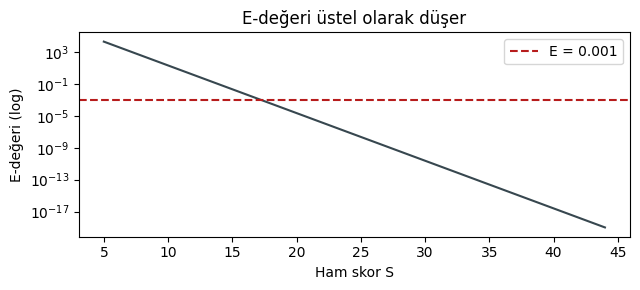

E < 0.001 için gereken minimum ham skor: 18


In [7]:
# E-değerinin skorla değişimi (bizim veritabanı boyutu için)
n_vt = sum(map(len, vt.values()))
Sler = np.arange(5, 45)
plt.figure(figsize=(6.5, 3))
plt.semilogy(Sler, [e_degeri(s, len(sorgu), n_vt) for s in Sler], color="#37474f")
plt.axhline(1e-3, color="#b71c1c", ls="--", label="E = 0.001")
plt.xlabel("Ham skor S"); plt.ylabel("E-değeri (log)"); plt.legend(); plt.title("E-değeri üstel olarak düşer"); plt.tight_layout(); plt.show()
S_esik = next(s for s in Sler if e_degeri(s, len(sorgu), n_vt) < 1e-3)
print("E < 0.001 için gereken minimum ham skor:", S_esik)

### 3.2 Mini-BLAST uygulaması

In [8]:
ESLESME, UYUMSUZ = 1, -3

def indeks_olustur(vt, w):
    ind = defaultdict(list)
    for sid, s in vt.items():
        for i in range(len(s) - w + 1):
            ind[s[i:i + w]].append((sid, i))
    return ind

def xdrop_genislet(q, s, qi, si, w, X=10):
    '''Tohumu (qi, si, w) iki yöne boşluksuz genişletir; (skor, q_bas, q_bit, s_bas) döndürür.'''
    skor = w * ESLESME
    # sağa
    en_iyi, en_iyi_sag, cur = skor, 0, skor
    k = 0
    while qi + w + k < len(q) and si + w + k < len(s):
        cur += ESLESME if q[qi + w + k] == s[si + w + k] else UYUMSUZ
        k += 1
        if cur > en_iyi:
            en_iyi, en_iyi_sag = cur, k
        if en_iyi - cur > X:
            break
    skor = en_iyi
    # sola
    en_iyi, en_iyi_sol, cur = skor, 0, skor
    k = 0
    while qi - k - 1 >= 0 and si - k - 1 >= 0:
        cur += ESLESME if q[qi - k - 1] == s[si - k - 1] else UYUMSUZ
        k += 1
        if cur > en_iyi:
            en_iyi, en_iyi_sol = cur, k
        if en_iyi - cur > X:
            break
    return en_iyi, qi - en_iyi_sol, qi + w + en_iyi_sag, si - en_iyi_sol

def mini_blast(sorgu, vt, w=11, X=10, e_esik=10):
    ind = indeks_olustur(vt, w)
    n = sum(map(len, vt.values()))
    en_iyi = {}
    tohum_sayisi = 0
    kapsanan = {}                           # köşegen -> genişletilmiş bölgenin sorgu üzerindeki sonu
    for qi in range(len(sorgu) - w + 1):
        for sid, si in ind.get(sorgu[qi:qi + w], []):
            tohum_sayisi += 1
            kosegen = (sid, si - qi)
            if qi < kapsanan.get(kosegen, -1):   # bu tohum önceki bir HSP'nin içinde kalıyor
                continue
            skor, qb, qs, sb = xdrop_genislet(sorgu, vt[sid], qi, si, w, X)
            kapsanan[kosegen] = qs
            if sid not in en_iyi or skor > en_iyi[sid][0]:
                en_iyi[sid] = (skor, qb, qs, sb)
    satirlar = [{"id": sid, "skor": sk, "bit": round(bit_skoru(sk), 1), "E": e_degeri(sk, len(sorgu), n),
                 "sorgu_bas": qb, "sorgu_bit": qs, "hedef_bas": sb}
                for sid, (sk, qb, qs, sb) in en_iyi.items()]
    df = pd.DataFrame(satirlar)
    if len(df):
        df = df[df.E <= e_esik].sort_values("E").reset_index(drop=True)
    return df, tohum_sayisi

t = time.time()
sonuc11, n_tohum = mini_blast(sorgu, vt, w=11)
print(f"w=11: {n_tohum} tohum isabeti, {time.time()-t:.2f} s")
sonuc11.style.format({"E": "{:.2e}"})

w=11: 374 tohum isabeti, 0.19 s


,id,skor,bit,E,sorgu_bas,sorgu_bit,hedef_bas
0,db_005,264,523.800000,5.45e-151,0,300,115
1,db_023,179,355.300000,2.88e-100,0,279,111
2,db_047,34,67.900000,9.74e-14,106,244,136
3,db_102,33,65.900000,3.85e-13,0,65,130
4,db_081,28,56.000000,3.71e-10,236,272,302
5,db_116,12,24.300000,1.31e+00,286,298,149
6,db_045,11,22.300000,5.17e+00,174,185,7
7,db_078,11,22.300000,5.17e+00,87,98,515


In [9]:
def degerlendir(sonuc, esik=1e-3):
    bulunan = set(sonuc[sonuc.E < esik].id)
    g = set(gercek.id)
    tp, fp, fn = len(bulunan & g), len(bulunan - g), len(g - bulunan)
    return tp, fp, fn, sorted(g - bulunan)

for w in [7, 9, 11, 15]:
    t = time.time()
    s_, nt = mini_blast(sorgu, vt, w=w)
    tp, fp, fn, kacan = degerlendir(s_)
    print(f"w={w:2d}: süre={time.time()-t:5.2f}s tohum={nt:6d}  doğru={tp} yanlış+={fp} kaçan={fn} {kacan}")
print("\nKaçan dizilerin mutasyon oranları:")
print(gercek[["id", "mutasyon_orani", "indel_orani"]])

w= 7: süre= 0.05s tohum=  2141  doğru=5 yanlış+=0 kaçan=1 ['db_133']


w= 9: süre= 0.20s tohum=   572  doğru=5 yanlış+=0 kaçan=1 ['db_133']


w=11: süre= 0.13s tohum=   374  doğru=5 yanlış+=0 kaçan=1 ['db_133']


w=15: süre= 0.21s tohum=   251  doğru=5 yanlış+=0 kaçan=1 ['db_133']



Kaçan dizilerin mutasyon oranları:
       id  mutasyon_orani  indel_orani
0  db_005            0.05         0.00
1  db_023            0.10         0.00
2  db_047            0.20         0.00
3  db_081            0.30         0.00
4  db_102            0.12         0.03
5  db_133            0.45         0.00


**Gözlem:** Kelime boyu (w) küçüldükçe tohum sayısı (yani iş yükü) hızla artar; gerçek, milyarlarca bazlık veritabanlarında bu fark
dakikalar ile saatler arasındaki farktır. Küçük w uzak homologlara karşı daha hassastır; bu küçük veride tüm w değerleri aynı beş homoloğu buldu. %45 mutasyonlu dizi DNA düzeyinde neredeyse
rastgeledir (rastgele iki DNA dizisi zaten ~%25 özdeştir); bu tür uzak homologlar **protein düzeyinde** (blastp/tblastx) aranmalıdır.

### 3.3 Karşılaştırma: tüm veritabanında Smith–Waterman (kesin arama)

In [10]:
from Bio import Align
sw = Align.PairwiseAligner(mode="local", match_score=1, mismatch_score=-3, open_gap_score=-5, extend_gap_score=-2)
t = time.time()
sw_skor = pd.DataFrame([{"id": sid, "SW_skor": sw.score(sorgu, s)} for sid, s in vt.items()])
print(f"SW tam tarama: {time.time()-t:.2f} s")
sw_skor["E"] = [e_degeri(s, len(sorgu), n_vt) for s in sw_skor.SW_skor]   # yaklaşık (boşluksuz λ,K)
sw_skor["gercek_homolog"] = sw_skor.id.isin(gercek.id)
sw_skor.sort_values("SW_skor", ascending=False).head(10)

SW tam tarama: 0.13 s


,id,SW_skor,E,gercek_homolog
5,db_005,264.0,5.451791e-151,True
23,db_023,179.0,2.884841e-100,True
102,db_102,132.0,3.215729e-72,True
47,db_047,34.0,9.740618e-14,True
81,db_081,28.0,3.707445e-10,True
116,db_116,12.0,1.309312e+00,False
45,db_045,11.0,5.173581e+00,False
78,db_078,11.0,5.173581e+00,False
34,db_034,10.0,2.044275e+01,False
52,db_052,10.0,2.044275e+01,False


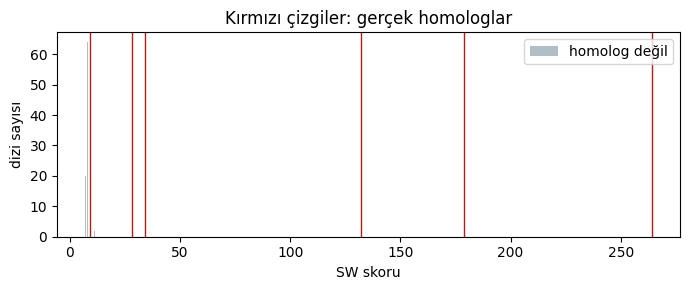

In [11]:
plt.figure(figsize=(7, 3))
plt.hist(sw_skor[~sw_skor.gercek_homolog].SW_skor, bins=20, color="#b0bec5", label="homolog değil")
for _, r in sw_skor[sw_skor.gercek_homolog].iterrows():
    plt.axvline(r.SW_skor, color="#b71c1c", lw=1)
plt.xlabel("SW skoru"); plt.ylabel("dizi sayısı"); plt.title("Kırmızı çizgiler: gerçek homologlar"); plt.legend(); plt.tight_layout(); plt.show()

In [12]:
# En iyi isabetin boşluklu hizalaması
en_iyi_id = sonuc11.id.iloc[0]
print(en_iyi_id)
print(sw.align(sorgu, vt[en_iyi_id])[0])

db_005
target            0 TTTCCTCATGCAATTCAAAACCATGTCCGTAATGTAGGCGAAATAGTAAACCATTTTACG
                  0 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query           115 TTTCCTCATGCAATTCAAAACCATGTCCGTAATGTAGGCGAAATAGTAAACCATTTTACG

target           60 GAGGATACCAAATTCCTCCTTATTCAGGACCTAACCTGAGGTAAACCAGGTCTCTCCGCC
                 60 ||||||||||||||||||||||||||||..|||||||||.||||||||||||||||||||
query           175 GAGGATACCAAATTCCTCCTTATTCAGGCGCTAACCTGACGTAAACCAGGTCTCTCCGCC

target          120 CCCTTATAAAAGCTGTTGCACCTAGCCAAGTTCAACGGCAGCTGCAATGGAAATAGGCAA
                120 ||||.|||||||||||||||||||||||||||||||||.|||||||||||||||.|||||
query           235 CCCTCATAAAAGCTGTTGCACCTAGCCAAGTTCAACGGAAGCTGCAATGGAAATGGGCAA

target          180 TGACGGATATATATTAAAAAGTGTTTTAAGATACATTGAGGCCCGTTCGTGCTCCTCGCC
                180 |||||||||||||||||||||||||||||||||||||||.||||||||||||||||.|||
query           295 TGACGGATATATATTAAAAAGTGTTTTAAGATACATTGATGCCCGTTCGTGCTCCTTGCC

target          2

## 4. (İsteğe bağlı) NCBI BLAST'ı Biopython ile çalıştırmak
`NCBIWWW.qblast` NCBI sunucularında BLAST çalıştırır; kuyruk nedeniyle **birkaç dakika** sürebilir. Aşağıdaki hücrede
`CALISTIR = True` yaparak deneyebilirsiniz. Sonuç XML formatında gelir ve `Bio.Blast` ile ayrıştırılır.

In [13]:
CALISTIR = False     # denemek için True yapın (internet gerekir, 1-5 dk sürebilir)

if CALISTIR:
    from Bio.Blast import NCBIWWW
    from Bio import Blast
    protein = "MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLSPDDIEQWFTEDPGP"   # p53'ün N-ucu
    with NCBIWWW.qblast("blastp", "swissprot", protein, hitlist_size=10) as h:
        open("blast_sonuc.xml", "w").write(h.read())
    with open("blast_sonuc.xml", "rb") as h:
        kayitlar = Blast.read(h)
    for hit in kayitlar:
        hsp = hit[0]
        print(f"{hit.target.id:25s} E={hsp.annotations['evalue']:.1e}  bit={hsp.annotations['bit score']:.1f}  {hit.target.description[:50]}")
else:
    print("Atlandı. (CALISTIR=False)")

Atlandı. (CALISTIR=False)


### BLAST sonucu nasıl okunur?

| Alan | Anlamı | Tipik eşik |
|---|---|---|
| E-value | Bu skor ya da daha iyisinin rastlantıyla beklenen sayısı | < 1e-5 güvenilir homoloji |
| Bit score | Veritabanından bağımsız normalize skor | > 50 genellikle anlamlı |
| % Identity | Hizalanan bölgedeki özdeşlik | Proteinde > %30 ("alacakaranlık bölgesi" < %25) |
| Query coverage | Sorgunun ne kadarının hizalandığı | Kısa isabetlere dikkat |

## 5. Alıştırmalar
1. Eşleşme +2, uyumsuzluk −3 için λ'yı hesaplayın. K = 0.62 kabul ederek m = 500, n = 10⁹ için E = 10⁻¹⁰ olması gereken minimum skoru bulun.
2. Veritabanı 10 kat büyürse aynı skorlu bir isabetin E-değeri nasıl değişir? Bit skoru değişir mi?
3. `mini_blast` fonksiyonuna **iki-isabet (two-hit)** kuralı ekleyin: aynı köşegende birbirine en fazla A = 40 baz uzaklıkta iki tohum olmadan genişletme yapılmasın. Tohum/genişletme sayısını ve sonuçları karşılaştırın.
4. Sorguyu ters tamamlayıcıya çevirip veritabanında arayın; bulunamıyorsa `mini_blast`'ı her iki ipliği tarayacak şekilde güncelleyin.

---
## Çözümler

In [14]:
# 1
L1 = lambda_bul(2, -3)
S_min = (math.log(0.62 * 500 * 1e9) - math.log(1e-10)) / L1
print(f"1) λ={L1:.3f}; gereken minimum S ≈ {S_min:.1f} -> {math.ceil(S_min)}")
# 2
print("2) E, n ile doğru orantılı -> 10 kat artar. Bit skoru puanlama sistemine bağlıdır; veritabanı boyutundan bağımsızdır, değişmez.")
# 3
def mini_blast_iki_isabet(sorgu, vt, w=11, A=40, X=10):
    ind = indeks_olustur(vt, w); son = {}; genislet = 0; en_iyi = {}
    for qi in range(len(sorgu) - w + 1):
        for sid, si in ind.get(sorgu[qi:qi + w], []):
            k = (sid, si - qi)
            if k in son and 0 < qi - son[k] <= A:
                genislet += 1
                sk, qb, qs, sb = xdrop_genislet(sorgu, vt[sid], qi, si, w, X)
                if sid not in en_iyi or sk > en_iyi[sid]:
                    en_iyi[sid] = sk
            son[k] = qi
    return en_iyi, genislet
r3, g3 = mini_blast_iki_isabet(sorgu, vt, w=9)
print("3) iki-isabet ile genişletme sayısı:", g3, "| bulunan:", sorted(r3, key=r3.get, reverse=True)[:8])
# 4
from Bio.Seq import Seq
rc = str(Seq(sorgu).reverse_complement())
r4, _ = mini_blast(rc, vt, w=11)
print("4) ters tamamlayıcı sorgu ile E<0.001 isabet sayısı:", (r4.E < 1e-3).sum() if len(r4) else 0,
      "(homolog bölgeler veritabanında + iplikte olduğundan bulunamaz)")
def mini_blast_iki_iplik(sorgu, vt, **kw):
    a, _ = mini_blast(sorgu, vt, **kw); a["iplik"] = "+"
    b, _ = mini_blast(str(Seq(sorgu).reverse_complement()), vt, **kw); b["iplik"] = "-"
    return pd.concat([a, b]).sort_values("E").reset_index(drop=True)
print(mini_blast_iki_iplik(rc, vt).head())

1) λ=0.634; gereken minimum S ≈ 78.1 -> 79
2) E, n ile doğru orantılı -> 10 kat artar. Bit skoru puanlama sistemine bağlıdır; veritabanı boyutundan bağımsızdır, değişmez.


3) iki-isabet ile genişletme sayısı: 465 | bulunan: ['db_005', 'db_023', 'db_047', 'db_102', 'db_081', 'db_116', 'db_078', 'db_045']


4) ters tamamlayıcı sorgu ile E<0.001 isabet sayısı: 0 (homolog bölgeler veritabanında + iplikte olduğundan bulunamaz)


       id  skor    bit              E  sorgu_bas  sorgu_bit  hedef_bas iplik
0  db_005   264  523.8  5.451791e-151          0        300        115     -
1  db_023   179  355.3  2.884841e-100          0        279        111     -
2  db_047    34   67.9   9.740618e-14        106        244        136     -
3  db_102    33   65.9   3.848882e-13          0         65        130     -
4  db_081    28   56.0   3.707445e-10        236        272        302     -
